# KV cache simulation — plots

Reads `../results/results_<dataset>.csv` written by `run_one.py` (or `run_all.py`).
The `DATASET` variable below (or env `KV_SIM_PLOT_DATASET`) must match `--dataset` used when running experiments.

All three plots (page size, eviction, ordering) load from the same unified CSV and filter by the relevant columns.
Use the commented-out `.query(...)` lines in each cell to narrow the data if needed.

In [34]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..").resolve()
RES = ROOT / "results"

# Match `experiments/*.py --dataset` (or set env KV_SIM_PLOT_DATASET)
DATASET = os.environ.get("KV_SIM_PLOT_DATASET", "loogle")
# DATASET = 'narrativeqa'
DATASET = 'sharegpt_90k_raw'

In [35]:
def load_results_csv(dataset: str | None = None) -> pd.DataFrame | None:
    """Load ``results_{dataset}.csv`` written by run_one.py."""
    dataset = dataset or DATASET
    p = RES / f"results_{dataset}.csv"
    if not p.is_file():
        print(f"Missing {p}")
        return None
    return pd.read_csv(p)

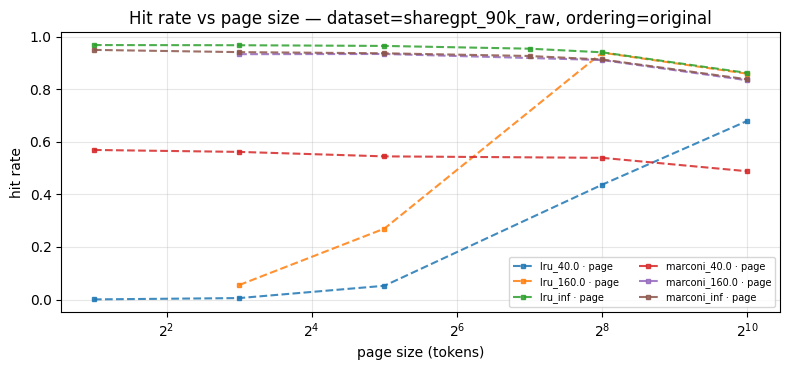

In [36]:
df_ps = load_results_csv()
ordering = "original"  # or min_distance, max_distance, random
# ordering = "random"  # or min_distance, max_distance, random
if df_ps is not None and len(df_ps):
    # If one CSV mixes runs, narrow here, e.g.:
    # df_ps = df_ps.query("ordering == 'original' and capacity_spec == 'inf'")

    df_ps = df_ps.copy()
    df_ps["page_size"] = pd.to_numeric(df_ps["page_size"], errors="coerce")
    # df_ps = df_ps[df_ps["capacity_spec"] == "inf"]

    df_ps = df_ps.dropna(subset=["page_size"]).sort_values("page_size")

    ds_list = sorted(df_ps["dataset"].dropna().unique())
    if not ds_list:
        print("No 'dataset' column values to plot.")
    else:
        fig, axes = plt.subplots(
            len(ds_list), 1, figsize=(8, max(3.5, 3.8 * len(ds_list))), squeeze=False
        )
        cmap = plt.get_cmap("tab10")
        for ax, ds in zip(axes.ravel(), ds_list):
            sub = df_ps[df_ps["dataset"] == ds]
            sub = sub[sub["ordering"] == ordering]
            strategies = sorted(sub["strategy"].dropna().unique())
            capacity = sorted(sub["capacity_spec"].dropna().unique())
            colj = 0
            for strat in strategies:
                for cap in capacity:
                    if cap not in ["inf", float("inf"), 40, 160]:
                        continue
                    g = sub[sub["strategy"] == strat]
                    g = g[g["capacity_spec"] == cap].sort_values("page_size")
                    c = cmap(colj % 10)
                    colj = colj + 1
                    # ax.plot(
                    #     g["page_size"],
                    #     g["token_level_hit_rate"],
                    #     "o-",
                    #     color=c,
                    #     label=f"{strat}_{cap} · token",
                    #     ms=4,
                    # )
                    ax.plot(
                        g["page_size"],
                        g["page_level_hit_rate"],
                        "s--",
                        color=c,
                        label=f"{strat}_{cap} · page",
                        ms=3,
                        alpha=0.85,
                    )
            ax.set_xscale("log", base=2)
            ax.set_xlabel("page size (tokens)")
            ax.set_ylabel("hit rate")
            ax.legend(loc="best", fontsize=7, ncol=2)
            ax.set_title(f"Hit rate vs page size — dataset={ds}, ordering={ordering}")
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

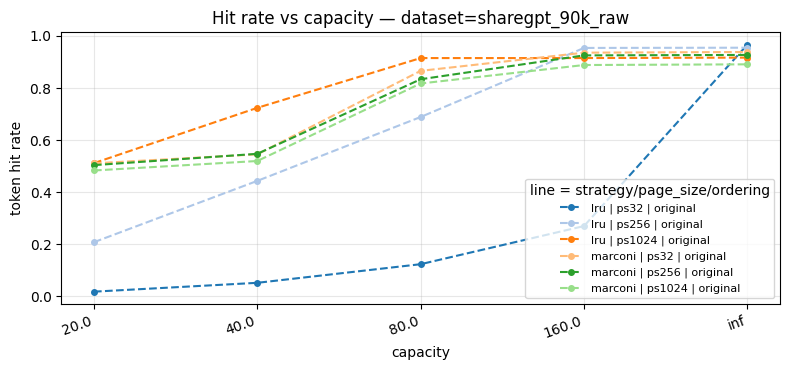

In [37]:
def _capacity_rank(s) -> float:
    t = str(s).lower().replace("gb", "").strip()
    if t in ("inf", "none", "unlimited", "nan"):
        return float("inf")
    try:
        return float(t)
    except ValueError:
        return float("nan")


def plot_hit_rate_vs_capacity(
    df: pd.DataFrame,
    page_sizes: list | None = None,
    strategies: list | None = None,
    orderings: list | None = None,
):
    """
    Plot token hit rate vs capacity.

    - page_sizes / strategies / orderings:
      Empty list or None means no filtering for that field.
    - A different line is drawn whenever any of
      (strategy, page_size, ordering) differs.
    """
    if df is None or not len(df):
        print("No data to plot.")
        return

    data = df.copy()
    data["page_size"] = pd.to_numeric(data["page_size"], errors="coerce")
    data["_cap_r"] = data["capacity_spec"].map(_capacity_rank)

    if page_sizes:
        data = data[data["page_size"].isin(page_sizes)]
    if strategies:
        data = data[data["strategy"].isin(strategies)]
    if orderings:
        data = data[data["ordering"].isin(orderings)]

    ds_list = sorted(data["dataset"].dropna().unique())
    if not ds_list:
        print("No rows left after filtering.")
        return

    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(8, max(3.5, 3.8 * len(ds_list))), squeeze=False
    )
    cmap = plt.get_cmap("tab20")

    for ax, ds in zip(axes.ravel(), ds_list):
        sub = data[data["dataset"] == ds]
        caps_df = sub.drop_duplicates("capacity_spec").sort_values("_cap_r")
        xlabels = [str(x) for x in caps_df["capacity_spec"]]
        xpos = {lab: i for i, lab in enumerate(xlabels)}

        groups = (
            sub.dropna(subset=["strategy", "page_size", "ordering"])
            .groupby(["strategy", "page_size", "ordering"], dropna=False)
        )

        for idx, ((strat, ps, ordering), g) in enumerate(groups):
            g = g.sort_values("_cap_r")
            xs = [xpos[str(cs)] for cs in g["capacity_spec"]]
            c = cmap(idx % 20)
            label = f"{strat} | ps{int(ps)} | {ordering}"
            ax.plot(xs, g["token_level_hit_rate"], "o--", color=c, label=label, ms=4)

        ax.set_xticks(range(len(xlabels)))
        ax.set_xticklabels(xlabels, rotation=20, ha="right")
        ax.set_xlabel("capacity")
        ax.set_ylabel("token hit rate")
        ax.legend(title="line = strategy/page_size/ordering", fontsize=8)
        ax.set_title(f"Hit rate vs capacity — dataset={ds}")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


df_cap = load_results_csv()
plot_hit_rate_vs_capacity(
    df_cap,
    page_sizes=[32, 256, 1024],
    strategies=[],
    orderings=[],
)

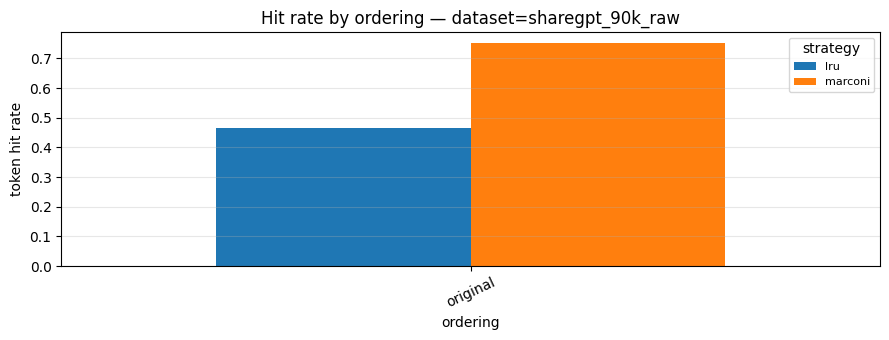

In [38]:
df_ord = load_results_csv()
if df_ord is not None and len(df_ord):
    # df_ord = df_ord.query("page_size == 32 and capacity_spec == 'inf'")
    ds_list = sorted(df_ord["dataset"].dropna().unique())
    fig, axes = plt.subplots(
        len(ds_list), 1, figsize=(9, max(3.2, 3.5 * len(ds_list))), squeeze=False
    )
    for ax, ds in zip(axes.ravel(), ds_list):
        sub = df_ord[df_ord["dataset"] == ds]
        pivot = sub.pivot_table(
            index="ordering",
            columns="strategy",
            values="token_level_hit_rate",
            aggfunc="mean",
        )
        pivot.plot(kind="bar", ax=ax, rot=25, width=0.82)
        ax.set_ylabel("token hit rate")
        ax.set_xlabel("ordering")
        ax.legend(title="strategy", fontsize=8)
        ax.set_title(f"Hit rate by ordering — dataset={ds}")
        ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [39]:
# Load/compute ratio CDF: need per-request ratios from JSON (or re-run sim).
# Placeholder: CDF of per-request rates from a single detailed JSON if you export traces.
import json

json_dir = RES / "page_size_json"
if json_dir.is_dir():
    files = sorted(json_dir.glob("*.json"))
    if files:
        print("Example: inspect", files[0].name, "for future per-request CDF export.")